In [1]:
# Cell 1: Imports and config

import os
import random
import json
import shutil
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from scipy.ndimage import rotate, gaussian_filter

warnings.filterwarnings("ignore")


SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


N_CLIENTS = 50
CLIENTS_PER_ROUND = 10
ROUNDS = 100
LOCAL_EPOCHS = 3
BATCH_SIZE = 32
CANDIDATE_POOL_SIZE = 20
PROXY_VAL_SIZE = 5000

# ================= MODELS =================
MODEL_NAMES = ["simple_cnn", "lenet", "logreg", "svm", "rf"]
CNN_MODELS = {"simple_cnn", "lenet"}

# ================= STRATEGIES =================
STRATEGIES = ["greedy", "shapley"]
K_VALUES = [5, 10]

# ================= DRIFT SCENARIOS =================
DRIFT_SCENARIOS = [
    "phase4_label_shift",
    "phase4_feature_shift",
]


FEATURE_SHIFT_MAX_PIXELS = 5
FEATURE_ROTATION_MAX_DEG = 15
FEATURE_BLUR_MAX_SIGMA = 1.0
FEATURE_NOISE_MAX_STD = 0.05

LABEL_CORRUPTION_MAX = 0.15


PHASE2_EVENT_FRACTIONS = [0.35, 0.70]
PHASE4_EVENT_FRACTIONS = [0.20, 0.40, 0.60, 0.80]


USE_CLEAN_TEST_ONLY = True

print("TensorFlow :", tf.__version__)
print("Scenarios  :", DRIFT_SCENARIOS)
print("Clean eval :", USE_CLEAN_TEST_ONLY)

TensorFlow : 2.20.0
Scenarios  : ['phase4_label_shift', 'phase4_feature_shift']
Clean eval : True


In [2]:
# Mount Drive and create checkpoint folder

from google.colab import drive

drive.mount("/content/drive", force_remount=False)

BASE_SAVE_DIR_TASK2 = Path("/content/drive/MyDrive/federated_learning_task2_checkpoints")
BASE_SAVE_DIR_TASK2.mkdir(parents=True, exist_ok=True)

print("Checkpoint folder:", BASE_SAVE_DIR_TASK2)

Mounted at /content/drive
Checkpoint folder: /content/drive/MyDrive/federated_learning_task2_checkpoints


In [3]:
# Load MNIST and prepare data

(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_full = y_train_full.astype(np.int64)
y_test = y_test.astype(np.int64)


X_train_full_flat = x_train_full.reshape(-1, 28 * 28)
X_test_flat = x_test.reshape(-1, 28 * 28)

X_train_full_img = x_train_full.reshape(-1, 28, 28, 1)
X_test_img = x_test.reshape(-1, 28, 28, 1)


X_test_img_clean = X_test_img.copy()
X_test_flat_clean = X_test_flat.copy()
y_test_clean = y_test.copy()


X_test_img_drift_base = X_test_img.copy()
X_test_flat_drift_base = X_test_flat.copy()
y_test_drift_base = y_test.copy()


X_pool_flat, X_proxy_flat, y_pool, y_proxy = train_test_split(
    X_train_full_flat,
    y_train_full,
    test_size=PROXY_VAL_SIZE,
    random_state=SEED,
    stratify=y_train_full
)

X_pool_img = X_pool_flat.reshape(-1, 28, 28, 1)
X_proxy_img = X_proxy_flat.reshape(-1, 28, 28, 1)


scaler = StandardScaler()


X_pool_scaled = scaler.fit_transform(X_pool_flat)


X_proxy_scaled = scaler.transform(X_proxy_flat)
X_test_scaled_clean = scaler.transform(X_test_flat_clean)


X_test_scaled_drift_base = scaler.transform(X_test_flat_drift_base)


classes = np.arange(10)


n_pool = len(X_pool_flat)
indices = np.arange(n_pool)

rng = np.random.default_rng(SEED)
rng.shuffle(indices)

client_indices = np.array_split(indices, N_CLIENTS)


print("Pool shape:", X_pool_flat.shape)
print("Proxy shape:", X_proxy_flat.shape)
print("Clean test shape:", X_test_flat_clean.shape)
print("Classes:", classes)
print("Clients:", len(client_indices))
print("Samples/client (approx):", len(client_indices[0]))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Pool shape: (55000, 784)
Proxy shape: (5000, 784)
Clean test shape: (10000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]
Clients: 50
Samples/client (approx): 1100


In [4]:
# Non-IID client split

def shard_partition(y, n_clients=50, shards_per_client=4, seed=SEED):
    """
    Creates a shard-based non-IID partition.

    Each client receives only a few shards, so most clients see
    only a limited subset of classes.
    """
    rng = np.random.default_rng(seed)

    idx_sorted = np.argsort(y)

    n_shards = n_clients * shards_per_client
    shards = np.array_split(idx_sorted, n_shards)

    rng.shuffle(shards)

    client_indices = []

    for i in range(n_clients):
        chunk = shards[i * shards_per_client:(i + 1) * shards_per_client]
        client_indices.append(np.concatenate(chunk))

    return client_indices


def client_label_histograms(y, client_indices, n_classes=10):
    """
    Computes normalized label distributions for each client.

    Used for:
    - Greedy diversity selection
    - Understanding client heterogeneity
    """
    hists = np.zeros((len(client_indices), n_classes), dtype=np.float32)

    for cid, idx in enumerate(client_indices):
        counts = np.bincount(y[idx], minlength=n_classes).astype(np.float32)
        hists[cid] = counts / (counts.sum() + 1e-9)

    return hists


def client_entropy(hist):
    """
    Measures how mixed a client's label distribution is.
    Lower entropy = more label-specialized client.
    """
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + 1e-12))


def summarize_client_distributions(y, client_indices, num_clients_to_show=5):
    """
    Prints class counts and entropy for a few clients.
    Useful to verify strong non-IID behavior.
    """
    for cid in range(min(num_clients_to_show, len(client_indices))):
        idx = client_indices[cid]
        counts = np.bincount(y[idx], minlength=10)
        hist = counts / (counts.sum() + 1e-9)
        ent = client_entropy(hist)

        print(f"Client {cid}")
        print(" Counts :", counts.tolist())
        print(" Entropy:", round(float(ent), 3))
        print("-" * 50)


client_indices = shard_partition(
    y_pool,
    n_clients=N_CLIENTS,
    shards_per_client=4,
    seed=SEED
)

client_hists = client_label_histograms(
    y_pool,
    client_indices,
    n_classes=10
)


global_label_dist = np.bincount(y_pool, minlength=10)
global_label_dist = global_label_dist / global_label_dist.sum()

print("Number of clients:", len(client_indices))
print("Samples per client (first 5):", [len(client_indices[i]) for i in range(5)])

print("\nGlobal label distribution:")
print(np.round(global_label_dist, 3))

print("\nSample client label distributions:")
summarize_client_distributions(y_pool, client_indices, num_clients_to_show=5)

Number of clients: 50
Samples per client (first 5): [1100, 1100, 1100, 1100, 1100]

Global label distribution:
[0.099 0.112 0.099 0.102 0.097 0.09  0.099 0.104 0.098 0.099]

Sample client label distributions:
Client 0
 Counts : [0, 275, 275, 0, 0, 275, 0, 275, 0, 0]
 Entropy: 2.0
--------------------------------------------------
Client 1
 Counts : [275, 275, 0, 275, 0, 0, 0, 0, 275, 0]
 Entropy: 2.0
--------------------------------------------------
Client 2
 Counts : [0, 275, 275, 0, 0, 0, 0, 275, 275, 0]
 Entropy: 2.0
--------------------------------------------------
Client 3
 Counts : [0, 275, 0, 0, 0, 275, 0, 275, 0, 275]
 Entropy: 2.0
--------------------------------------------------
Client 4
 Counts : [0, 275, 275, 0, 0, 0, 275, 0, 0, 275]
 Entropy: 2.0
--------------------------------------------------


In [5]:
# Greedy selection and Shapley-style scoring

def cosine_distance(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-9
    return 1.0 - float(np.dot(a, b) / denom)


def greedy_diverse_select(candidate_clients, k, hists):
    """
    Greedily selects a diverse subset of clients by maximizing
    minimum pairwise label-distribution distance.
    """
    candidate_clients = list(candidate_clients)

    if len(candidate_clients) <= k:
        return candidate_clients

    rng = np.random.default_rng(SEED)

    selected = [int(rng.choice(candidate_clients))]
    remaining = [c for c in candidate_clients if c not in selected]

    while len(selected) < k and len(remaining) > 0:
        best_client = None
        best_score = -1.0

        for cid in remaining:
        
            score = min(
                cosine_distance(hists[cid], hists[s])
                for s in selected
            )

            if score > best_score:
                best_score = score
                best_client = cid

        selected.append(best_client)
        remaining.remove(best_client)

    return selected



def client_drift_priority(cid, hist):
    """
    Clients with concentrated label distributions are often more informative
    after drift because they represent more specialized local concepts.
    """
    entropy = client_entropy(hist)

    # Lower entropy => higher priority
    priority = 1.0 / (1.0 + entropy)
    return float(priority)


def compute_proxy_scores(
    client_indices,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    sample_per_client=200
):
    """
    Computes a lightweight proxy usefulness score for each client.
    Higher score => better candidate for Shapley-style selection.
    """
    scores = {}
    rng = np.random.default_rng(SEED)

    for cid, idx in enumerate(client_indices):
        idx = np.asarray(idx)

    
        if len(idx) < 20:
            scores[cid] = 0.0
            continue

        use_idx = idx
        if len(use_idx) > sample_per_client:
            use_idx = rng.choice(
                use_idx,
                size=sample_per_client,
                replace=False
            )

        y_local = y_train[use_idx]

        
        if len(np.unique(y_local)) < 2:
            scores[cid] = 0.0
            continue

        proxy_clf = SGDClassifier(
            loss="log_loss",
            alpha=1e-4,
            max_iter=100,
            tol=1e-3,
            class_weight="balanced",
            random_state=SEED
        )

        try:
            proxy_clf.fit(X_train_scaled[use_idx], y_local)
            pred = proxy_clf.predict(X_val_scaled)

            proxy_acc = accuracy_score(y_val, pred)

            # Small bonus for specialized clients
            drift_bonus = 0.05 * client_drift_priority(
                cid,
                client_hists[cid]
            )

            scores[cid] = float(proxy_acc + drift_bonus)

        except Exception:
            scores[cid] = 0.0

    return scores



client_proxy_scores = compute_proxy_scores(
    client_indices,
    X_pool_scaled,
    y_pool,
    X_proxy_scaled,
    y_proxy,
    sample_per_client=200
)



def shapley_like_select(candidate_clients, k, proxy_scores):
    """
    Select top-k clients according to proxy utility scores.
    """
    ranked = sorted(
        candidate_clients,
        key=lambda c: proxy_scores.get(c, 0.0),
        reverse=True
    )

    return ranked[:k]


def hybrid_select(candidate_clients, k, hists, proxy_scores, alpha=0.5):
    """
    Combines diversity and proxy score.
    alpha near 1.0 => more weight on proxy utility
    alpha near 0.0 => more weight on diversity
    """
    candidate_clients = list(candidate_clients)

    if len(candidate_clients) <= k:
        return candidate_clients

    rng = np.random.default_rng(SEED)

    selected = [int(rng.choice(candidate_clients))]
    remaining = [c for c in candidate_clients if c not in selected]

    while len(selected) < k and len(remaining) > 0:
        best_client = None
        best_score = -1.0

        for cid in remaining:
            diversity_score = min(
                cosine_distance(hists[cid], hists[s])
                for s in selected
            )

            proxy_score = proxy_scores.get(cid, 0.0)

            combined_score = (
                (1.0 - alpha) * diversity_score +
                alpha * proxy_score
            )

            if combined_score > best_score:
                best_score = combined_score
                best_client = cid

        selected.append(best_client)
        remaining.remove(best_client)

    return selected


print("Proxy score sample:")
print({i: round(client_proxy_scores[i], 4) for i in range(5)})

Proxy score sample:
{0: 0.3899, 1: 0.3959, 2: 0.3907, 3: 0.3763, 4: 0.3975}


In [6]:
# Models



def build_simple_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),

        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.30),

        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_lenet():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),

        tf.keras.layers.Conv2D(
            6,
            (5, 5),
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(
            16,
            (5, 5),
            activation="relu"
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(120, activation="relu"),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Dense(84, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=8e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_logreg():
    return LogisticRegression(
        max_iter=300,
        solver="saga",
        penalty="l2",
        C=0.8,
        multi_class="multinomial",
        n_jobs=-1,
        random_state=SEED
    )


def build_svm():
    return SGDClassifier(
        loss="hinge",
        alpha=1e-4,
        max_iter=1,
        tol=None,
        learning_rate="optimal",
        random_state=SEED
    )


def build_rf():
    return RandomForestClassifier(
        n_estimators=120,
        max_depth=16,
        min_samples_split=4,
        min_samples_leaf=2,
        bootstrap=True,
        warm_start=False,
        random_state=SEED,
        n_jobs=-1
    )



def initialize_model(model_name):
    if model_name == "simple_cnn":
        return build_simple_cnn()

    if model_name == "lenet":
        return build_lenet()

    if model_name == "logreg":
        return build_logreg()

    if model_name == "svm":
        return build_svm()

    if model_name == "rf":
        return build_rf()

    raise ValueError(f"Unknown model: {model_name}")


print("Model builders ready.")

Model builders ready.


In [7]:
# Drift helpers

# ================= BASIC IMAGE SHIFT =================
def shift_images_batch(x, shift_x=0, shift_y=0):
    x_shifted = np.roll(x, shift=shift_x, axis=1)
    x_shifted = np.roll(x_shifted, shift=shift_y, axis=2)
    return x_shifted


# ================= BASIC IMAGE ROTATION =================
def rotate_images_batch(x, angle):
    rotated = np.zeros_like(x)

    for i in range(len(x)):
        rotated[i, :, :, 0] = rotate(
            x[i, :, :, 0],
            angle=angle,
            reshape=False,
            order=1,
            mode="nearest"
        )

    return rotated


# ================= BASIC IMAGE BLUR =================
def blur_images_batch(x, sigma):
    blurred = np.zeros_like(x)

    for i in range(len(x)):
        blurred[i, :, :, 0] = gaussian_filter(
            x[i, :, :, 0],
            sigma=sigma
        )

    return blurred


# ================= LABEL MAPS =================

LABEL_MAP_PHASE_1 = {
    0: 1, 1: 0,
    2: 7, 7: 2
}

LABEL_MAP_PHASE_2 = {
    3: 8, 8: 3,
    4: 9, 9: 4
}

LABEL_MAP_PHASE_3 = {
    5: 6, 6: 5
}


def apply_feature_drift(x_img, round_idx, total_rounds, scenario="gradual_feature_shift"):
    x = x_img.copy()

    drift_start = int(0.35 * total_rounds)

    if round_idx < drift_start:
        return x

    progress = (round_idx - drift_start) / (total_rounds - drift_start)
    progress = np.clip(progress, 0.0, 1.0)

    rng = np.random.default_rng(SEED + round_idx)

    if scenario == "gradual_feature_shift":

        # Moderate drift only
        shift_mag = int(np.round(2 * progress))      # max 2-pixel shift
        rotation_angle = 4 * progress                # max 4 degrees
        blur_sigma = 0.3 * progress                  # max mild blur
        noise_std = 0.003 + 0.01 * progress          # max 0.013
        brightness = 1.0 - 0.03 * progress           # max 3% dimming

        if shift_mag > 0:
            x = shift_images_batch(
                x,
                shift_x=shift_mag,
                shift_y=-shift_mag
            )

        if rotation_angle > 0.5:
            x = rotate_images_batch(x, rotation_angle)

        if blur_sigma > 0.05:
            x = blur_images_batch(x, blur_sigma)

        x = x * brightness

        if noise_std > 0:
            x += rng.normal(0, noise_std, x.shape).astype(np.float32)

    return np.clip(x, 0.0, 1.0)


def get_num_drift_events(scenario):
    if "phase4" in scenario:
        return 4
    if "phase2" in scenario:
        return 2
    return 0


def get_event_rounds(total_rounds, n_events):
    if n_events == 2:
        return [
            int(0.35 * total_rounds),
            int(0.70 * total_rounds)
        ]

    if n_events == 4:
        return [
            int(0.20 * total_rounds),
            int(0.40 * total_rounds),
            int(0.60 * total_rounds),
            int(0.80 * total_rounds)
        ]

    return []


def get_current_phase(round_idx, total_rounds, n_events):
    event_rounds = get_event_rounds(total_rounds, n_events)
    return sum(round_idx >= r for r in event_rounds)



def apply_phased_feature_drift(x_img, round_idx, total_rounds, scenario):
    x = x_img.copy()

    n_events = get_num_drift_events(scenario)
    phase = get_current_phase(round_idx, total_rounds, n_events)

    if phase == 0:
        return x

    rng = np.random.default_rng(SEED + round_idx)

 
    feature_settings = [
        (0, 0, 0.0, 0.00, 0.000, 1.00),
        (1, 0, 2.0, 0.20, 0.005, 0.99),
        (1, -1, 4.0, 0.35, 0.008, 0.98),
        (-1, 1, 5.0, 0.50, 0.010, 0.97),
        (2, 1, 6.0, 0.60, 0.012, 0.96),
    ]

    sx, sy, angle, blur_sigma, noise_std, brightness = feature_settings[
        min(phase, len(feature_settings) - 1)
    ]

    if sx != 0 or sy != 0:
        x = shift_images_batch(x, shift_x=sx, shift_y=sy)

    if abs(angle) > 0:
        x = rotate_images_batch(x, angle)

    if blur_sigma > 0:
        x = blur_images_batch(x, blur_sigma)

    x = x * brightness

    if noise_std > 0:
        x += rng.normal(0, noise_std, x.shape).astype(np.float32)

    return np.clip(x, 0.0, 1.0)



def apply_phased_label_shift(X_img, y, round_idx, total_rounds, scenario):
    X_new = X_img.copy()
    y_new = y.copy()

    n_events = get_num_drift_events(scenario)
    phase = get_current_phase(round_idx, total_rounds, n_events)

    if phase == 0:
        return X_new, y_new

    rng = np.random.default_rng(SEED + round_idx)

    
    if "phase2" in scenario:
        corruption_rates = [0.0, 0.18, 0.28]
    else:
        corruption_rates = [0.0, 0.18, 0.32, 0.48, 0.60]

    corruption_rate = corruption_rates[
        min(phase, len(corruption_rates) - 1)
    ]

    mask = rng.random(len(y_new)) < corruption_rate
    drift_indices = np.where(mask)[0]

    if phase == 1:
        label_map = {
            0: 1, 1: 0,
            2: 7, 7: 2
        }

    elif phase == 2:
        label_map = {
            0: 1, 1: 0,
            2: 7, 7: 2,
            3: 8, 8: 3,
            4: 9, 9: 4
        }

    else:
        label_map = {
            0: 1, 1: 0,
            2: 7, 7: 2,
            3: 8, 8: 3,
            4: 9, 9: 4,
            5: 6, 6: 5
        }

    for idx in drift_indices:
        current_label = int(y_new[idx])
        y_new[idx] = label_map.get(current_label, current_label)

    return X_new, y_new

In [8]:
# Checkpoint helpers

BASE_SAVE_DIR_TASK2 = Path("/content/drive/MyDrive/federated_learning_task2_checkpoints")
BASE_SAVE_DIR_TASK2.mkdir(parents=True, exist_ok=True)



def exp_dir_task2(model_name, strategy, k, drift_scenario):
    d = BASE_SAVE_DIR_TASK2 / f"{model_name}__{strategy}__K{k}__{drift_scenario}"
    d.mkdir(parents=True, exist_ok=True)
    return d


def history_path_task2(d):
    return d / "history.json"


def keras_model_path_task2(d):
    return d / "model.keras"


def joblib_model_path_task2(d):
    return d / "model.joblib"


def metadata_path_task2(d):
    return d / "metadata.json"



def save_history_task2(d, payload):
    try:
        with open(history_path_task2(d), "w") as f:
            json.dump(payload, f)

    except Exception as e:
        print("Warning: Failed to save history:", e)


def load_history_task2(d):
    p = history_path_task2(d)

    if not p.exists():
        return None

    try:
        with open(p, "r") as f:
            return json.load(f)

    except Exception:
        return None


def save_metadata_task2(d, metadata):
    try:
        with open(metadata_path_task2(d), "w") as f:
            json.dump(metadata, f)

    except Exception as e:
        print("Warning: Failed to save metadata:", e)


def load_metadata_task2(d):
    p = metadata_path_task2(d)

    if not p.exists():
        return None

    try:
        with open(p, "r") as f:
            return json.load(f)

    except Exception:
        return None


def save_model_task2(d, model_name, model):
    try:
        if model is None:
            return

        if model_name in CNN_MODELS:
            model.save(
                keras_model_path_task2(d),
                overwrite=True
            )
        else:
            joblib.dump(
                model,
                joblib_model_path_task2(d)
            )

    except Exception as e:
        print("Warning: Failed to save model:", e)


def load_model_task2(d, model_name):
    try:
        if model_name in CNN_MODELS:
            p = keras_model_path_task2(d)

            if not p.exists():
                return None

            return tf.keras.models.load_model(p)

        else:
            p = joblib_model_path_task2(d)

            if not p.exists():
                return None

            return joblib.load(p)

    except Exception:
        return None


def checkpoint_exists_task2(model_name, strategy, k, drift_scenario):
    d = exp_dir_task2(model_name, strategy, k, drift_scenario)

    history_exists = history_path_task2(d).exists()

    if model_name in CNN_MODELS:
        model_exists = keras_model_path_task2(d).exists()
    else:
        model_exists = joblib_model_path_task2(d).exists()

    return history_exists and model_exists


def reset_experiment_dir(model_name, strategy, k, drift_scenario):
    d = exp_dir_task2(model_name, strategy, k, drift_scenario)

    if d.exists():
        shutil.rmtree(d)

    d.mkdir(parents=True, exist_ok=True)

    print("Reset experiment folder:", d)


def reset_all_experiments():
    if BASE_SAVE_DIR_TASK2.exists():
        shutil.rmtree(BASE_SAVE_DIR_TASK2)

    BASE_SAVE_DIR_TASK2.mkdir(parents=True, exist_ok=True)

    print("Reset all Task 2 checkpoints.")

In [9]:
# Data helpers, training, and evaluation

def get_candidate_clients(round_idx, candidate_pool_size=CANDIDATE_POOL_SIZE):
    rng = np.random.default_rng(SEED + round_idx)

    return rng.choice(
        N_CLIENTS,
        size=min(candidate_pool_size, N_CLIENTS),
        replace=False
    ).tolist()


def get_selected_clients(candidate_clients, strategy, k):
    if strategy == "greedy":
        return greedy_diverse_select(candidate_clients, k, client_hists)

    if strategy == "shapley":
        return shapley_like_select(candidate_clients, k, client_proxy_scores)

    raise ValueError(f"Unknown strategy: {strategy}")


def get_round_data_drift(selected_clients, round_idx, total_rounds, drift_scenario):
    idx = np.concatenate([client_indices[c] for c in selected_clients])

    X_round_img = X_pool_img[idx].copy()
    y_round = y_pool[idx].copy()

    if drift_scenario == "gradual_feature_shift":
        X_round_img = apply_feature_drift(
            X_round_img,
            round_idx,
            total_rounds,
            drift_scenario
        )

    elif drift_scenario in ["phase2_feature_shift", "phase4_feature_shift"]:
        X_round_img = apply_phased_feature_drift(
            X_round_img,
            round_idx,
            total_rounds,
            drift_scenario
        )

    elif drift_scenario == "gradual_label_shift":
        y_round = apply_label_drift(
            y_round,
            round_idx,
            total_rounds,
            drift_scenario
        )

    elif drift_scenario in ["phase2_label_shift", "phase4_label_shift"]:
        X_round_img, y_round = apply_phased_label_shift(
            X_round_img,
            y_round,
            round_idx,
            total_rounds,
            drift_scenario
        )

    X_round_flat = X_round_img.reshape(-1, 28 * 28)
    X_round_scaled = scaler.transform(X_round_flat)

    return X_round_scaled, X_round_img, y_round


def get_eval_data_clean():
    return (
        X_test_scaled_clean,
        X_test_img_clean,
        y_test_clean
    )


def get_eval_data_drifted(round_idx, total_rounds, drift_scenario):
    X_eval_img = X_test_img_clean.copy()
    y_eval = y_test_clean.copy()

    if drift_scenario == "gradual_feature_shift":
        X_eval_img = apply_feature_drift(
            X_eval_img,
            round_idx,
            total_rounds,
            drift_scenario
        )

    elif drift_scenario in ["phase2_feature_shift", "phase4_feature_shift"]:
        X_eval_img = apply_phased_feature_drift(
            X_eval_img,
            round_idx,
            total_rounds,
            drift_scenario
        )

    elif drift_scenario == "gradual_label_shift":
        y_eval = apply_label_drift(
            y_eval,
            round_idx,
            total_rounds,
            drift_scenario
        )

    elif drift_scenario in ["phase2_label_shift", "phase4_label_shift"]:
        X_eval_img, y_eval = apply_phased_label_shift(
            X_eval_img,
            y_eval,
            round_idx,
            total_rounds,
            drift_scenario
        )

    X_eval_flat = X_eval_img.reshape(-1, 28 * 28)
    X_eval_scaled = scaler.transform(X_eval_flat)

    return X_eval_scaled, X_eval_img, y_eval


def evaluate_model_drift(model_name, model, round_idx, total_rounds, drift_scenario):
    # -------- CLEAN TEST ACCURACY --------
    X_eval_scaled_clean, X_eval_img_clean_local, y_eval_clean = get_eval_data_clean()

    if model_name in CNN_MODELS:
        probs_clean = model.predict(X_eval_img_clean_local, verbose=0)
        preds_clean = np.argmax(probs_clean, axis=1)
    else:
        preds_clean = model.predict(X_eval_scaled_clean)

    clean_acc = accuracy_score(y_eval_clean, preds_clean)

    # -------- DRIFTED TEST ACCURACY --------
    X_eval_scaled_drift, X_eval_img_drift, y_eval_drift = get_eval_data_drifted(
        round_idx,
        total_rounds,
        drift_scenario
    )

    if model_name in CNN_MODELS:
        probs_drift = model.predict(X_eval_img_drift, verbose=0)
        preds_drift = np.argmax(probs_drift, axis=1)
    else:
        preds_drift = model.predict(X_eval_scaled_drift)

    drifted_acc = accuracy_score(y_eval_drift, preds_drift)

    return clean_acc, drifted_acc


def train_one_round_drift(model_name, model, X_round_scaled, X_round_img, y_round):

    # -------- SIMPLE CNN --------
    if model_name == "simple_cnn":
        if model is None:
            model = build_simple_cnn()

        model.fit(
            X_round_img,
            y_round,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            shuffle=True
        )

        return model

    # -------- LENET --------
    if model_name == "lenet":
        if model is None:
            model = build_lenet()

        model.fit(
            X_round_img,
            y_round,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            shuffle=True
        )

        return model

    # -------- LOGISTIC REGRESSION --------
    if model_name == "logreg":
        model = build_logreg()
        model.fit(X_round_scaled, y_round)
        return model

    # -------- SVM (Incremental Learning) --------
    if model_name == "svm":
        if model is None:
            model = build_svm()
            model.partial_fit(X_round_scaled, y_round, classes=classes)
        else:
            model.partial_fit(X_round_scaled, y_round)

        return model

    # -------- RANDOM FOREST --------
    if model_name == "rf":
        model = build_rf()
        model.fit(X_round_scaled, y_round)
        return model

    raise ValueError(f"Unknown model: {model_name}")

In [10]:
# Drift helpers

# ================= BASIC IMAGE SHIFT =================
def shift_images_batch(x, shift_x=0, shift_y=0):
    x_shifted = np.roll(x, shift=shift_x, axis=1)
    x_shifted = np.roll(x_shifted, shift=shift_y, axis=2)
    return x_shifted


# ================= BASIC IMAGE ROTATION =================
def rotate_images_batch(x, angle):
    rotated = np.zeros_like(x)
    for i in range(len(x)):
        rotated[i, :, :, 0] = rotate(
            x[i, :, :, 0],
            angle=angle,
            reshape=False,
            order=1,
            mode="nearest"
        )
    return rotated


# ================= BASIC IMAGE BLUR =================
def blur_images_batch(x, sigma):
    blurred = np.zeros_like(x)
    for i in range(len(x)):
        blurred[i, :, :, 0] = gaussian_filter(
            x[i, :, :, 0],
            sigma=sigma
        )
    return blurred


# ================= LABEL MAPS =================
LABEL_MAP_PHASE_1 = {
    0: 1, 1: 0,
    2: 7, 7: 2
}

LABEL_MAP_PHASE_2 = {
    3: 8, 8: 3,
    4: 9, 9: 4
}

LABEL_MAP_PHASE_3 = {
    5: 6, 6: 5
}


def apply_feature_drift(x_img, round_idx, total_rounds, scenario="gradual_feature_shift"):
    x = x_img.copy()

    drift_start = int(0.35 * total_rounds)
    if round_idx < drift_start:
        return x

    progress = (round_idx - drift_start) / (total_rounds - drift_start)
    progress = np.clip(progress, 0.0, 1.0)

    rng = np.random.default_rng(SEED + round_idx)

    if scenario == "gradual_feature_shift":
        shift_mag = int(np.round(2 * progress))   
        rotation_angle = 4 * progress             
        blur_sigma = 0.25 * progress              
        noise_std = 0.003 + 0.01 * progress       
        brightness = 1.0 - 0.03 * progress       

        if shift_mag > 0:
            x = shift_images_batch(x, shift_x=shift_mag, shift_y=-shift_mag)

        if rotation_angle > 0.5:
            x = rotate_images_batch(x, rotation_angle)

        if blur_sigma > 0.05:
            x = blur_images_batch(x, blur_sigma)

        x = x * brightness

        if noise_std > 0:
            x += rng.normal(0, noise_std, x.shape).astype(np.float32)

    return np.clip(x, 0.0, 1.0)



def get_num_drift_events(scenario):
    if "phase4" in scenario:
        return 4
    if "phase2" in scenario:
        return 2
    return 0


def get_event_rounds(total_rounds, n_events):
    if n_events == 2:
        return [int(0.35 * total_rounds), int(0.70 * total_rounds)]
    if n_events == 4:
        return [
            int(0.20 * total_rounds),
            int(0.40 * total_rounds),
            int(0.60 * total_rounds),
            int(0.80 * total_rounds),
        ]
    return []


def get_current_phase(round_idx, total_rounds, n_events):
    event_rounds = get_event_rounds(total_rounds, n_events)
    return sum(round_idx >= r for r in event_rounds)


# ================= PHASE FEATURE DRIFT =================
def apply_phased_feature_drift(x_img, round_idx, total_rounds, scenario):
    x = x_img.copy()

    n_events = get_num_drift_events(scenario)
    phase = get_current_phase(round_idx, total_rounds, n_events)

    if phase == 0:
        return x

    rng = np.random.default_rng(SEED + round_idx)

   
    feature_settings = [
        (0, 0, 0.0, 0.00, 1.00),
        (1, 0, 2.0, 0.20, 0.99),
        (1, -1, 4.0, 0.35, 0.98),
        (-1, 1, 5.0, 0.50, 0.97),
        (2, 1, 6.0, 0.60, 0.96),
    ]

    sx, sy, angle, blur_sigma, brightness = feature_settings[
        min(phase, len(feature_settings) - 1)
    ]

    noise_std = 0.005 + 0.004 * phase

    if sx != 0 or sy != 0:
        x = shift_images_batch(x, shift_x=sx, shift_y=sy)

    if abs(angle) > 0:
        x = rotate_images_batch(x, angle)

    if blur_sigma > 0:
        x = blur_images_batch(x, blur_sigma)

    x = x * brightness

    if noise_std > 0:
        x += rng.normal(0, noise_std, x.shape).astype(np.float32)

    return np.clip(x, 0.0, 1.0)


# ================= PHASE LABEL DRIFT =================
def apply_phased_label_shift(X_img, y, round_idx, total_rounds, scenario):
    X_new = X_img.copy()
    y_new = y.copy()

    n_events = get_num_drift_events(scenario)
    phase = get_current_phase(round_idx, total_rounds, n_events)

    if phase == 0:
        return X_new, y_new

    rng = np.random.default_rng(SEED + 2000 + round_idx)

   
    corruption_rates = [0.0, 0.15, 0.25, 0.35, 0.45]
    corruption_rate = corruption_rates[min(phase, len(corruption_rates) - 1)]

    mask = rng.random(len(y_new)) < corruption_rate
    drift_indices = np.where(mask)[0]

    if phase == 1:
        label_map = {**LABEL_MAP_PHASE_1}

    elif phase == 2:
        label_map = {**LABEL_MAP_PHASE_1, **LABEL_MAP_PHASE_2}

    else:
        label_map = {
            **LABEL_MAP_PHASE_1,
            **LABEL_MAP_PHASE_2,
            **LABEL_MAP_PHASE_3
        }

    for idx in drift_indices:
        current_label = int(y_new[idx])
        y_new[idx] = label_map.get(current_label, current_label)

    return X_new, y_new

In [11]:
def get_eval_data_drift(round_idx, total_rounds, drift_scenario):
    """
    Creates a drifted copy of the clean test set.
    Used only for optional drifted-accuracy reporting.
    """

    X_eval_img = X_test_img_clean.copy()
    y_eval = y_test_clean.copy()

    # ================= FEATURE DRIFT =================
    if drift_scenario == "gradual_feature_shift":
        X_eval_img = apply_feature_drift(
            X_eval_img,
            round_idx,
            total_rounds,
            drift_scenario
        )

    elif drift_scenario in ["phase2_feature_shift", "phase4_feature_shift"]:
        X_eval_img = apply_phased_feature_drift(
            X_eval_img,
            round_idx,
            total_rounds,
            drift_scenario
        )

    # ================= LABEL DRIFT =================

    elif drift_scenario in ["phase2_label_shift", "phase4_label_shift"]:
        X_eval_img, y_eval = apply_phased_label_shift(
            X_eval_img,
            y_eval,
            round_idx,
            total_rounds,
            drift_scenario
        )

    X_eval_flat = X_eval_img.reshape(-1, 28 * 28)
    X_eval_scaled = scaler.transform(X_eval_flat)

    return X_eval_scaled, X_eval_img, y_eval

In [12]:
# Resumable runner

def run_drift_experiment_resumable(
    model_name,
    strategy,
    k=CLIENTS_PER_ROUND,
    rounds=ROUNDS,
    candidate_pool_size=CANDIDATE_POOL_SIZE,
    drift_scenario="gradual_feature_shift",
    overwrite=False
):
    d = exp_dir_task2(model_name, strategy, k, drift_scenario)

    if overwrite and d.exists():
        shutil.rmtree(d)
        d.mkdir(parents=True, exist_ok=True)

    saved = load_history_task2(d)

    if saved is None:
        acc_history = []
        drifted_acc_history = []
        comm_history = []
        comp_history = []
        start_round = 0
        model = None
    else:
        acc_history = saved.get("accuracy", [])
        drifted_acc_history = saved.get("drifted_accuracy", [])
        comm_history = saved.get("communication", [])
        comp_history = saved.get("computation", [])
        start_round = saved.get("completed_rounds", 0)
        model = load_model_task2(d, model_name)

    print(f"Resuming from round {start_round + 1} in {d}")

    drift_events = get_event_rounds(
        rounds,
        get_num_drift_events(drift_scenario)
    )

    for r in range(start_round, rounds):

        try:

            candidate_clients = get_candidate_clients(
                r + 1000,
                candidate_pool_size
            )

            selected_clients = get_selected_clients(
                candidate_clients,
                strategy,
                k
            )

            X_round_scaled, X_round_img, y_round = get_round_data_drift(
                selected_clients,
                r,
                rounds,
                drift_scenario
            )

            model = train_one_round_drift(
                model_name,
                model,
                X_round_scaled,
                X_round_img,
                y_round
            )

            # CLEAN TEST ACCURACY

            X_eval_scaled_clean, X_eval_img_clean_local, y_eval_clean = get_eval_data_clean()

            if model_name in CNN_MODELS:
                probs_clean = model.predict(
                    X_eval_img_clean_local,
                    verbose=0
                )
                preds_clean = np.argmax(probs_clean, axis=1)
            else:
                preds_clean = model.predict(X_eval_scaled_clean)

            clean_acc = accuracy_score(y_eval_clean, preds_clean)


            # DRIFTED TEST ACCURACY

            X_eval_scaled_drifted, X_eval_img_drifted, y_eval_drifted = get_eval_data_drift(
                r,
                rounds,
                drift_scenario
            )

            if model_name in CNN_MODELS:
                probs_drifted = model.predict(
                    X_eval_img_drifted,
                    verbose=0
                )
                preds_drifted = np.argmax(probs_drifted, axis=1)
            else:
                preds_drifted = model.predict(X_eval_scaled_drifted)

            drifted_acc = accuracy_score(y_eval_drifted, preds_drifted)

        except Exception as e:
            print(f"Error at round {r+1}: {e}")
            continue

        acc_history.append(float(clean_acc))
        drifted_acc_history.append(float(drifted_acc))

        comm_history.append(int((r + 1) * k))
        comp_history.append(int((r + 1) * k * LOCAL_EPOCHS))

        save_history_task2(d, {
            "model_name": model_name,
            "strategy": strategy,
            "k": k,
            "rounds": rounds,
            "drift_scenario": drift_scenario,
            "completed_rounds": r + 1,
            "accuracy": acc_history,
            "drifted_accuracy": drifted_acc_history,
            "communication": comm_history,
            "computation": comp_history
        })

        save_model_task2(d, model_name, model)

        if (r == 0) or ((r + 1) % 5 == 0):

            marker = ""
            if r in drift_events:
                marker = " <-- DRIFT EVENT"

            print(
                f"[DRIFT | {model_name} | {strategy} | "
                f"K={k} | {drift_scenario}] "
                f"round {r+1:03d}/{rounds} "
                f"clean_acc={clean_acc:.4f} "
                f"drifted_acc={drifted_acc:.4f}"
                f"{marker}"
            )

    return (
        model,
        acc_history,
        drifted_acc_history,
        comm_history,
        comp_history
    )

In [13]:
# Run all Task 2 experiments automatically

task2_results = {}

for drift_scenario in DRIFT_SCENARIOS:

    print("\n" + "=" * 80)
    print(f"DRIFT SCENARIO: {drift_scenario}")
    print("=" * 80)

    for k in K_VALUES:
        for model_name in MODEL_NAMES:
            for strategy in STRATEGIES:

                exp_key = (model_name, strategy, k, drift_scenario)

                print(
                    f"\n=== Task 2: "
                    f"model={model_name}, "
                    f"strategy={strategy}, "
                    f"K={k}, "
                    f"drift={drift_scenario} ==="
                )

                try:
                    model, acc_hist, drifted_acc_hist, comm_hist, comp_hist = run_drift_experiment_resumable(
                        model_name=model_name,
                        strategy=strategy,
                        k=k,
                        rounds=ROUNDS,
                        candidate_pool_size=CANDIDATE_POOL_SIZE,
                        drift_scenario=drift_scenario,
                        overwrite=False
                    )

                    task2_results[exp_key] = {
                        "accuracy": acc_hist,
                        "drifted_accuracy": drifted_acc_hist,
                        "communication": comm_hist,
                        "computation": comp_hist
                    }

                    final_clean = acc_hist[-1] if len(acc_hist) > 0 else np.nan
                    best_clean = max(acc_hist) if len(acc_hist) > 0 else np.nan
                    final_drifted = drifted_acc_hist[-1] if len(drifted_acc_hist) > 0 else np.nan
                    best_drifted = max(drifted_acc_hist) if len(drifted_acc_hist) > 0 else np.nan

                    print(
                        f"✔ Final Clean Acc: {final_clean:.4f} | "
                        f"Best Clean Acc: {best_clean:.4f} | "
                        f"Final Drifted Acc: {final_drifted:.4f} | "
                        f"Best Drifted Acc: {best_drifted:.4f}"
                    )

                except Exception as e:
                    print(f"Failed for {exp_key}: {e}")
                    continue


DRIFT SCENARIO: phase4_label_shift

=== Task 2: model=simple_cnn, strategy=greedy, K=5, drift=phase4_label_shift ===
Resuming from round 101 in /content/drive/MyDrive/federated_learning_task2_checkpoints/simple_cnn__greedy__K5__phase4_label_shift
✔ Final Clean Acc: 0.0329 | Best Clean Acc: 0.9902 | Final Drifted Acc: 0.6353 | Best Drifted Acc: 0.9901

=== Task 2: model=simple_cnn, strategy=shapley, K=5, drift=phase4_label_shift ===
Resuming from round 101 in /content/drive/MyDrive/federated_learning_task2_checkpoints/simple_cnn__shapley__K5__phase4_label_shift
✔ Final Clean Acc: 0.0573 | Best Clean Acc: 0.9849 | Final Drifted Acc: 0.6270 | Best Drifted Acc: 0.9826

=== Task 2: model=lenet, strategy=greedy, K=5, drift=phase4_label_shift ===
Resuming from round 101 in /content/drive/MyDrive/federated_learning_task2_checkpoints/lenet__greedy__K5__phase4_label_shift
✔ Final Clean Acc: 0.0100 | Best Clean Acc: 0.9893 | Final Drifted Acc: 0.6416 | Best Drifted Acc: 0.9886

=== Task 2: model

In [14]:
# Save results after the experiment loop

import pickle

save_path = BASE_SAVE_DIR_TASK2 / "task2_results.pkl"

try:
    with open(save_path, "wb") as f:
        pickle.dump(task2_results, f)

    print("Saved task2_results to:", save_path)
    print("Total experiment configurations saved:", len(task2_results))

    sample_key = next(iter(task2_results.keys()))
    print("Sample experiment key:", sample_key)
    print("Stored fields:", list(task2_results[sample_key].keys()))

except Exception as e:
    print("Failed to save results:", e)

Saved task2_results to: /content/drive/MyDrive/federated_learning_task2_checkpoints/task2_results.pkl
Total experiment configurations saved: 40
Sample experiment key: ('simple_cnn', 'greedy', 5, 'phase4_label_shift')
Stored fields: ['accuracy', 'drifted_accuracy', 'communication', 'computation']


In [15]:
# Reprint logs from saved results

for (model_name, strategy, k, drift_scenario), data in task2_results.items():

    clean_hist = data.get("accuracy", [])
    drifted_hist = data.get("drifted_accuracy", [])

    print(
        f"\n=== Task 2: "
        f"model={model_name}, "
        f"strategy={strategy}, "
        f"K={k}, "
        f"drift={drift_scenario} ==="
    )

    n_events = get_num_drift_events(drift_scenario)
    drift_events = get_event_rounds(len(clean_hist), n_events)

    for r in range(len(clean_hist)):

        if (r == 0) or ((r + 1) % 5 == 0) or ((r + 1) == len(clean_hist)):

            clean_acc = clean_hist[r]

            drifted_acc = np.nan
            if r < len(drifted_hist):
                drifted_acc = drifted_hist[r]

            marker = ""
            if r in drift_events:
                marker = " <-- DRIFT EVENT"

            gap = np.nan
            if not np.isnan(drifted_acc):
                gap = clean_acc - drifted_acc

            print(
                f"[DRIFT | {model_name} | {strategy} | "
                f"K={k} | {drift_scenario}] "
                f"round {r+1:03d}/{len(clean_hist)} "
                f"clean_acc={clean_acc:.4f} "
                f"drifted_acc={drifted_acc:.4f} "
                f"gap={gap:.4f}"
                f"{marker}"
            )


=== Task 2: model=simple_cnn, strategy=greedy, K=5, drift=phase4_label_shift ===
[DRIFT | simple_cnn | greedy | K=5 | phase4_label_shift] round 001/100 clean_acc=0.9479 drifted_acc=0.9479 gap=0.0000
[DRIFT | simple_cnn | greedy | K=5 | phase4_label_shift] round 005/100 clean_acc=0.9784 drifted_acc=0.9784 gap=0.0000
[DRIFT | simple_cnn | greedy | K=5 | phase4_label_shift] round 010/100 clean_acc=0.9881 drifted_acc=0.9881 gap=0.0000
[DRIFT | simple_cnn | greedy | K=5 | phase4_label_shift] round 015/100 clean_acc=0.9843 drifted_acc=0.9843 gap=0.0000
[DRIFT | simple_cnn | greedy | K=5 | phase4_label_shift] round 020/100 clean_acc=0.9894 drifted_acc=0.9894 gap=0.0000
[DRIFT | simple_cnn | greedy | K=5 | phase4_label_shift] round 025/100 clean_acc=0.9892 drifted_acc=0.9034 gap=0.0858
[DRIFT | simple_cnn | greedy | K=5 | phase4_label_shift] round 030/100 clean_acc=0.9858 drifted_acc=0.9065 gap=0.0793
[DRIFT | simple_cnn | greedy | K=5 | phase4_label_shift] round 035/100 clean_acc=0.9787 drif

In [16]:
# Summary table

def first_round_reaching_threshold(history, threshold=0.80):
    for i, acc in enumerate(history, start=1):
        if acc >= threshold:
            return i
    return None


def accuracy_drop_after_drift(history, drift_scenario):
    """
    Measures the immediate drop after the first drift event.
    """

    n_events = get_num_drift_events(drift_scenario)

    if n_events == 0:
        return 0.0

    drift_points = get_event_rounds(len(history), n_events)

    if len(drift_points) == 0:
        return 0.0

    first_drift = drift_points[0]

    if first_drift <= 0 or first_drift >= len(history):
        return 0.0

    before = history[first_drift - 1]
    after = history[first_drift]

    return float(before - after)


def recovery_after_drift(history, drift_scenario, recovery_window=10):
    """
    Measures how much the model recovers within a few rounds
    after the first drift event.
    """

    n_events = get_num_drift_events(drift_scenario)

    if n_events == 0:
        return 0.0

    drift_points = get_event_rounds(len(history), n_events)

    if len(drift_points) == 0:
        return 0.0

    first_drift = drift_points[0]

    if first_drift >= len(history) - 1:
        return 0.0

    post_drift_acc = history[first_drift]

    end_idx = min(len(history), first_drift + recovery_window)
    recovered_acc = max(history[first_drift:end_idx])

    return float(recovered_acc - post_drift_acc)


def clean_vs_drift_gap(clean_hist, drifted_hist):
    """
    Average difference between clean accuracy and drifted accuracy.
    """

    if len(clean_hist) == 0 or len(drifted_hist) == 0:
        return np.nan

    n = min(len(clean_hist), len(drifted_hist))

    clean_vals = np.array(clean_hist[:n])
    drift_vals = np.array(drifted_hist[:n])

    return float(np.mean(clean_vals - drift_vals))


task2_summary = []

for (m, s, k, drift_scenario), data in task2_results.items():

    clean_hist = data.get("accuracy", [])
    drifted_hist = data.get("drifted_accuracy", [])

    if len(clean_hist) == 0:
        continue

    final_clean = clean_hist[-1]
    best_clean = max(clean_hist)
    mean_clean = float(np.mean(clean_hist))

    final_drifted = drifted_hist[-1] if len(drifted_hist) > 0 else np.nan
    best_drifted = max(drifted_hist) if len(drifted_hist) > 0 else np.nan
    mean_drifted = float(np.mean(drifted_hist)) if len(drifted_hist) > 0 else np.nan

    task2_summary.append({
        "model": m,
        "strategy": s,
        "K": k,
        "drift_scenario": drift_scenario,

        # ================= CLEAN TEST METRICS =================
        "final_clean_accuracy": final_clean,
        "best_clean_accuracy": best_clean,
        "mean_clean_accuracy": mean_clean,

        # ================= DRIFTED TEST METRICS =================
        "final_drifted_accuracy": final_drifted,
        "best_drifted_accuracy": best_drifted,
        "mean_drifted_accuracy": mean_drifted,

        # ================= GAP METRIC =================
        "avg_clean_drift_gap": clean_vs_drift_gap(
            clean_hist,
            drifted_hist
        ),

        # ================= CONVERGENCE =================
        "round_to_80pct": first_round_reaching_threshold(
            clean_hist,
            0.80
        ),

        # ================= DRIFT ROBUSTNESS =================
        "acc_drop_after_drift": accuracy_drop_after_drift(
            clean_hist,
            drift_scenario
        ),

        "recovery_after_drift": recovery_after_drift(
            clean_hist,
            drift_scenario
        ),

        # ================= COST =================
        "communication_cost": ROUNDS * k,
        "computation_cost_units": ROUNDS * k * LOCAL_EPOCHS
    })


# ================= CREATE DATAFRAME =================
task2_summary_df = pd.DataFrame(task2_summary)

task2_summary_df = task2_summary_df.sort_values(
    ["drift_scenario", "model", "K", "strategy"]
).reset_index(drop=True)

# ================= DISPLAY =================
print("Total summary rows:", len(task2_summary_df))

task2_summary_df

Total summary rows: 40


,model,strategy,K,drift_scenario,final_clean_accuracy,best_clean_accuracy,mean_clean_accuracy,final_drifted_accuracy,best_drifted_accuracy,mean_drifted_accuracy,avg_clean_drift_gap,round_to_80pct,acc_drop_after_drift,recovery_after_drift,communication_cost,computation_cost_units
0,lenet,greedy,5,phase4_feature_shift,0.9378,0.9876,0.970491,0.9901,0.9911,0.986835,-0.016344,1,0.0155,0.0106,500,1500
1,lenet,shapley,5,phase4_feature_shift,0.9033,0.9843,0.945415,0.9818,0.9876,0.964139,-0.018724,1,0.0447,0.1107,500,1500
2,lenet,greedy,10,phase4_feature_shift,0.9918,0.9932,0.989349,NaN,NaN,NaN,NaN,1,-0.0005,0.0023,1000,3000
3,lenet,shapley,10,phase4_feature_shift,0.9905,0.9905,0.986127,NaN,NaN,NaN,NaN,1,0.0003,0.0018,1000,3000
4,logreg,greedy,5,phase4_feature_shift,0.3774,0.9028,0.622562,0.5920,0.9028,0.602312,0.020250,1,0.1875,0.0000,500,1500
5,logreg,shapley,5,phase4_feature_shift,0.3703,0.8990,0.562860,0.5479,0.8990,0.556904,0.005956,1,0.2377,0.0428,500,1500
6,logreg,greedy,10,phase4_feature_shift,0.8815,0.8945,0.880559,NaN,NaN,NaN,NaN,1,0.0084,0.0128,1000,3000
7,logreg,shapley,10,phase4_feature_shift,0.8758,0.8925,0.873112,NaN,NaN,NaN,NaN,1,0.0138,0.0208,1000,3000
8,rf,greedy,5,phase4_feature_shift,0.4942,0.9388,0.757607,0.9190,0.9388,0.901359,-0.143752,1,0.1533,0.0699,500,1500
9,rf,shapley,5,phase4_feature_shift,0.4489,0.9202,0.715240,0.7710,0.9317,0.839537,-0.124297,1,0.1423,0.1297,500,1500


In [17]:
# Save summary to Drive

summary_csv = BASE_SAVE_DIR_TASK2 / "task2_summary.csv"
summary_excel = BASE_SAVE_DIR_TASK2 / "task2_summary.xlsx"

try:

    task2_summary_df.to_csv(summary_csv, index=False)

    task2_summary_df.to_excel(summary_excel, index=False)

    print("Saved summary CSV to:", summary_csv)
    print("Saved summary Excel to:", summary_excel)

    print("Summary rows:", len(task2_summary_df))
    print("Summary columns:", len(task2_summary_df.columns))
    print("Column names:")
    print(task2_summary_df.columns.tolist())

except Exception as e:
    print("Failed to save summary:", e)

Saved summary CSV to: /content/drive/MyDrive/federated_learning_task2_checkpoints/task2_summary.csv
Saved summary Excel to: /content/drive/MyDrive/federated_learning_task2_checkpoints/task2_summary.xlsx
Summary rows: 40
Summary columns: 16
Column names:
['model', 'strategy', 'K', 'drift_scenario', 'final_clean_accuracy', 'best_clean_accuracy', 'mean_clean_accuracy', 'final_drifted_accuracy', 'best_drifted_accuracy', 'mean_drifted_accuracy', 'avg_clean_drift_gap', 'round_to_80pct', 'acc_drop_after_drift', 'recovery_after_drift', 'communication_cost', 'computation_cost_units']


In [18]:
# Plot helper

def plot_task2_curves(model_name, drift_scenario, k=5):

    key_greedy = (model_name, "greedy", k, drift_scenario)
    key_shapley = (model_name, "shapley", k, drift_scenario)

    if key_greedy not in task2_results or key_shapley not in task2_results:
        print("Missing results for this configuration")
        return

    greedy_data = task2_results[key_greedy]
    shapley_data = task2_results[key_shapley]

    clean_greedy = greedy_data.get("accuracy", [])
    clean_shapley = shapley_data.get("accuracy", [])

    drifted_greedy = greedy_data.get("drifted_accuracy", [])
    drifted_shapley = shapley_data.get("drifted_accuracy", [])

    plt.figure(figsize=(12, 5))

    plt.plot(
        clean_greedy,
        linewidth=2,
        label="Greedy / DivFL (Clean)"
    )

    plt.plot(
        clean_shapley,
        linewidth=2,
        label="Shapley / S-FedAvg (Clean)"
    )

    if len(drifted_greedy) > 0:
        plt.plot(
            drifted_greedy,
            linestyle="--",
            alpha=0.7,
            label="Greedy / DivFL (Drifted)"
        )

    if len(drifted_shapley) > 0:
        plt.plot(
            drifted_shapley,
            linestyle="--",
            alpha=0.7,
            label="Shapley / S-FedAvg (Drifted)"
        )

    n_events = get_num_drift_events(drift_scenario)
    drift_points = get_event_rounds(len(clean_greedy), n_events)

    for i, dp in enumerate(drift_points):
        plt.axvline(x=dp, linestyle="--", linewidth=1)

        plt.text(
            dp + 0.5,
            0.50,
            f"Drift {i+1}",
            rotation=90,
            fontsize=8
        )

    plt.title(f"{model_name} under {drift_scenario} (K={k})")
    plt.xlabel("Communication Round")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.grid(True)
    plt.legend()
    plt.show()


DRIFT SCENARIO: phase4_label_shift
Drift event rounds: [20, 40, 60, 80]

Model: simple_cnn
Final Clean Accuracy | DivFL=0.0329 | S-FedAvg=0.0573


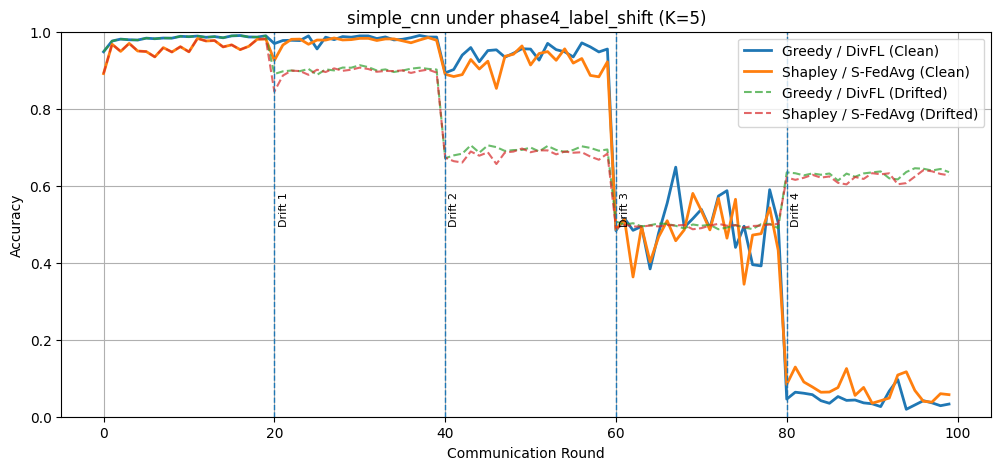


Model: lenet
Final Clean Accuracy | DivFL=0.0100 | S-FedAvg=0.0345


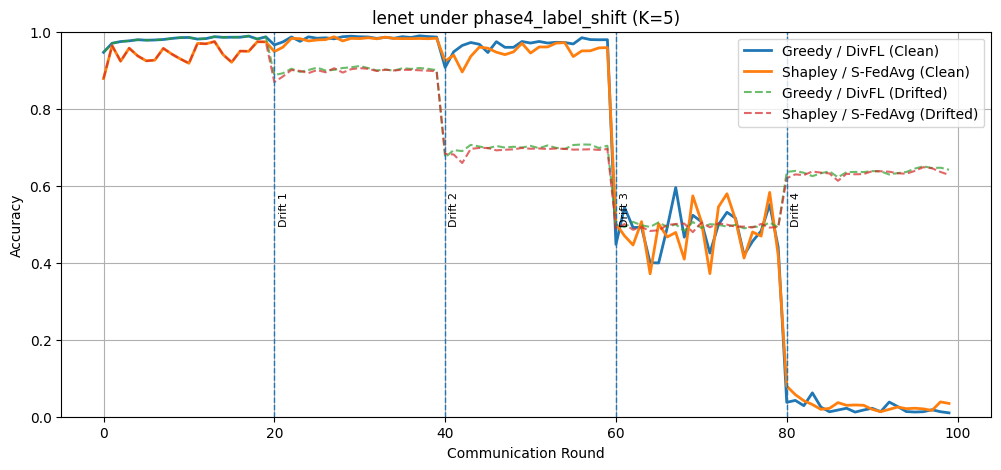


Model: logreg
Final Clean Accuracy | DivFL=0.1613 | S-FedAvg=0.2089


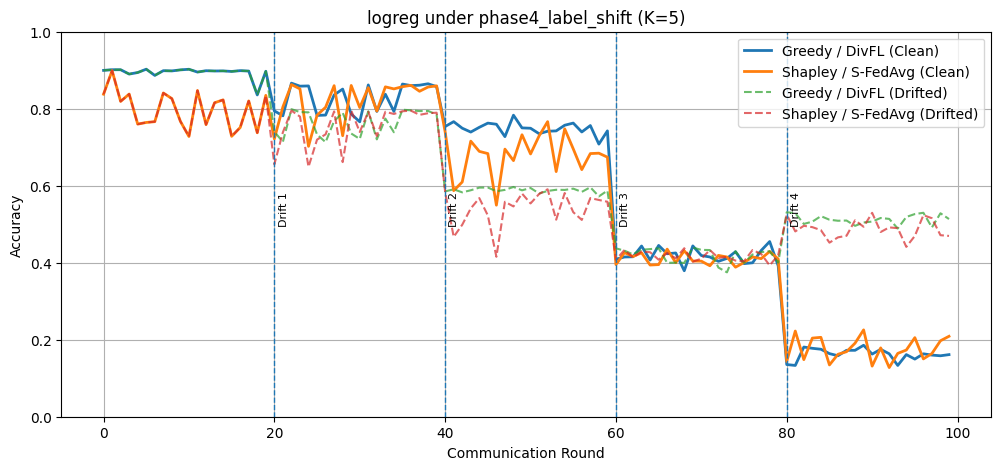


Model: svm
Final Clean Accuracy | DivFL=0.5939 | S-FedAvg=0.5433


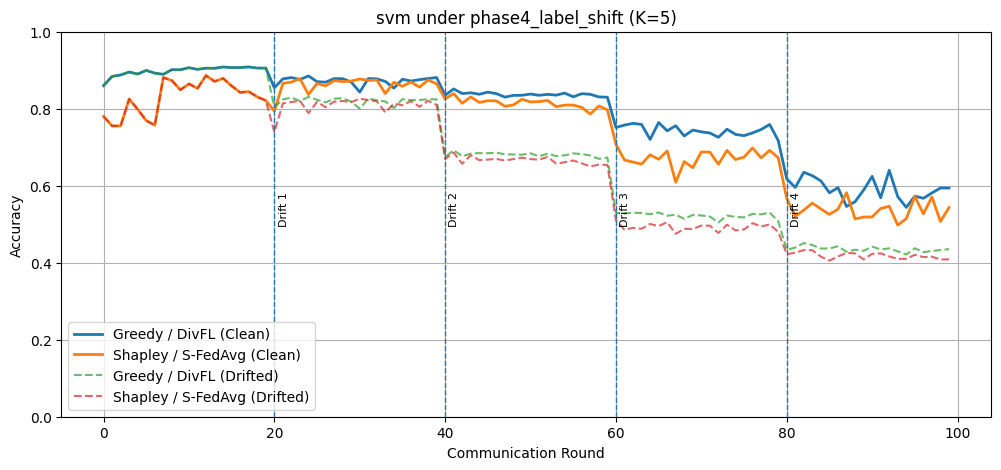


Model: rf
Final Clean Accuracy | DivFL=0.1066 | S-FedAvg=0.1682


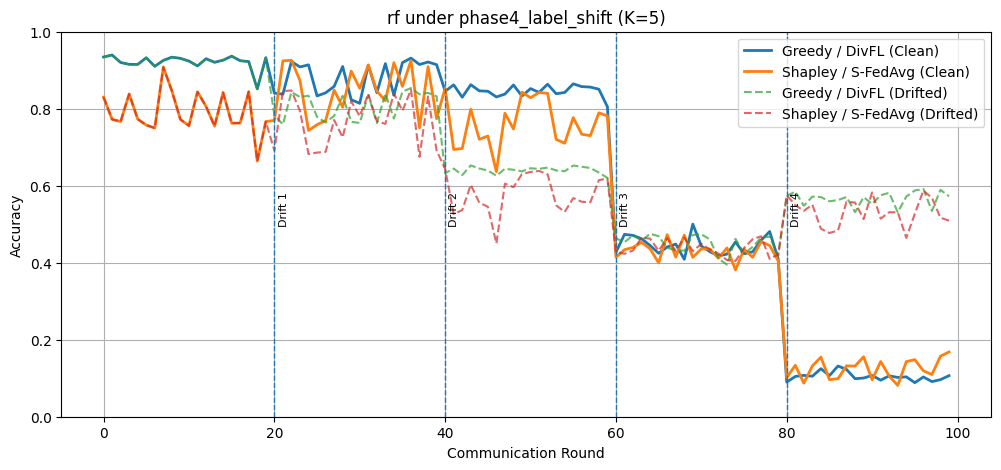


DRIFT SCENARIO: phase4_feature_shift
Drift event rounds: [20, 40, 60, 80]

Model: simple_cnn
Final Clean Accuracy | DivFL=0.8972 | S-FedAvg=0.8901


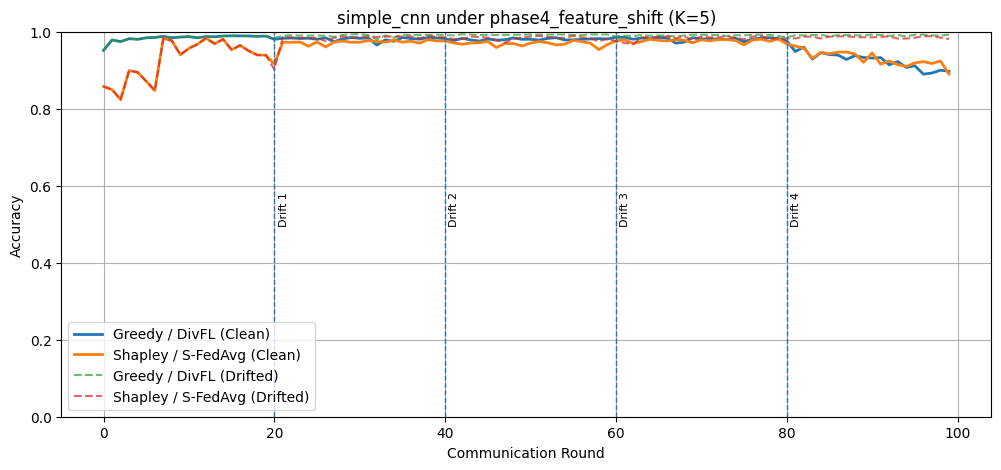


Model: lenet
Final Clean Accuracy | DivFL=0.9378 | S-FedAvg=0.9033


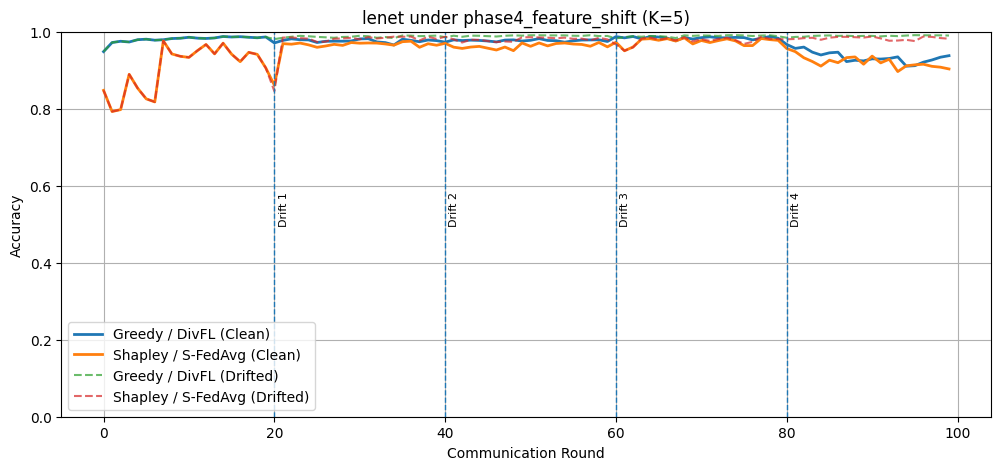


Model: logreg
Final Clean Accuracy | DivFL=0.3774 | S-FedAvg=0.3703


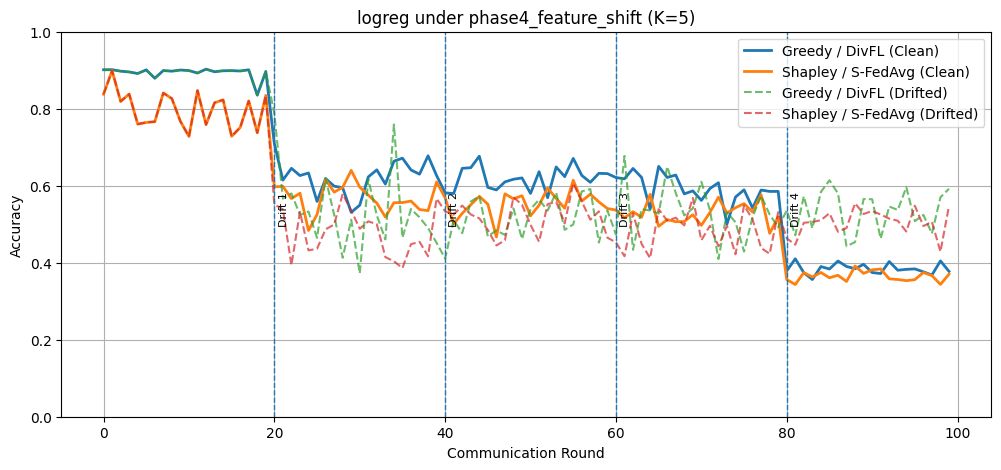


Model: svm
Final Clean Accuracy | DivFL=0.6028 | S-FedAvg=0.5785


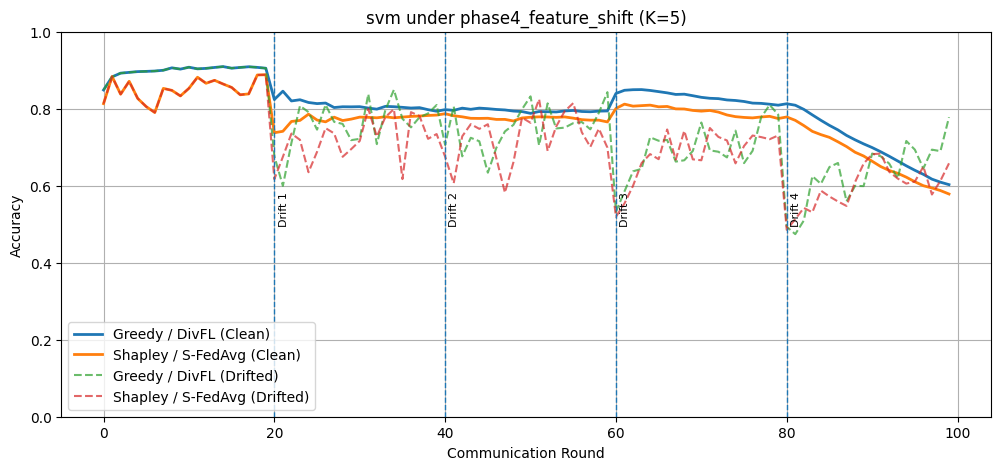


Model: rf
Final Clean Accuracy | DivFL=0.4942 | S-FedAvg=0.4489


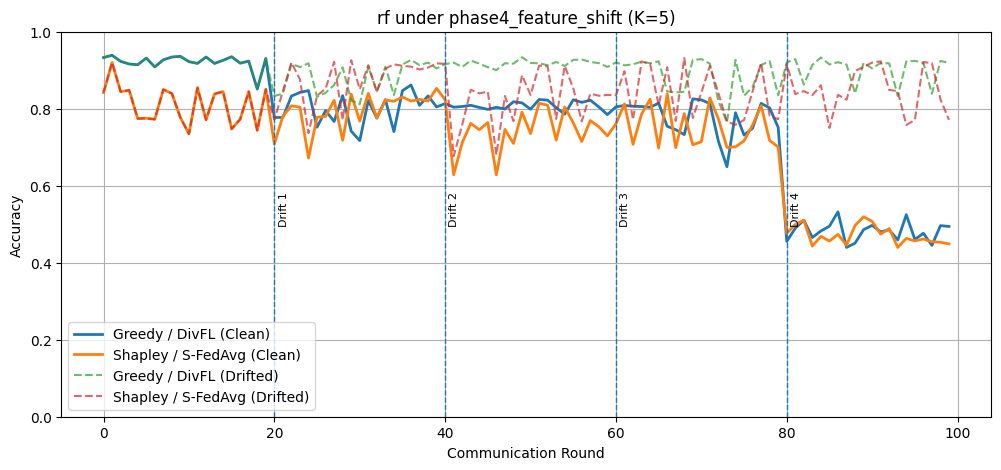

In [19]:
# Show plots for K=10

PLOT_K = 5

for drift_scenario in DRIFT_SCENARIOS:

    print("\n" + "=" * 70)
    print(f"DRIFT SCENARIO: {drift_scenario}")
    print("=" * 70)

    n_events = get_num_drift_events(drift_scenario)

    if n_events > 0:
        drift_points = get_event_rounds(ROUNDS, n_events)
        print("Drift event rounds:", drift_points)
    else:
        print("Continuous gradual drift scenario")

    for model_name in MODEL_NAMES:

        print(f"\nModel: {model_name}")

        key_greedy = (model_name, "greedy", PLOT_K, drift_scenario)
        key_shapley = (model_name, "shapley", PLOT_K, drift_scenario)

        if key_greedy not in task2_results or key_shapley not in task2_results:
            print("Missing experiment results")
            continue

        try:
            greedy_clean = task2_results[key_greedy]["accuracy"]
            shapley_clean = task2_results[key_shapley]["accuracy"]

            greedy_final = greedy_clean[-1] if len(greedy_clean) > 0 else np.nan
            shapley_final = shapley_clean[-1] if len(shapley_clean) > 0 else np.nan

            print(
                f"Final Clean Accuracy | "
                f"DivFL={greedy_final:.4f} | "
                f"S-FedAvg={shapley_final:.4f}"
            )

            plot_task2_curves(
                model_name=model_name,
                drift_scenario=drift_scenario,
                k=PLOT_K
            )

        except Exception as e:
            print(f"Failed to plot for {model_name}, {drift_scenario}: {e}")


FINAL ACCURACY vs K | DRIFT: phase4_label_shift


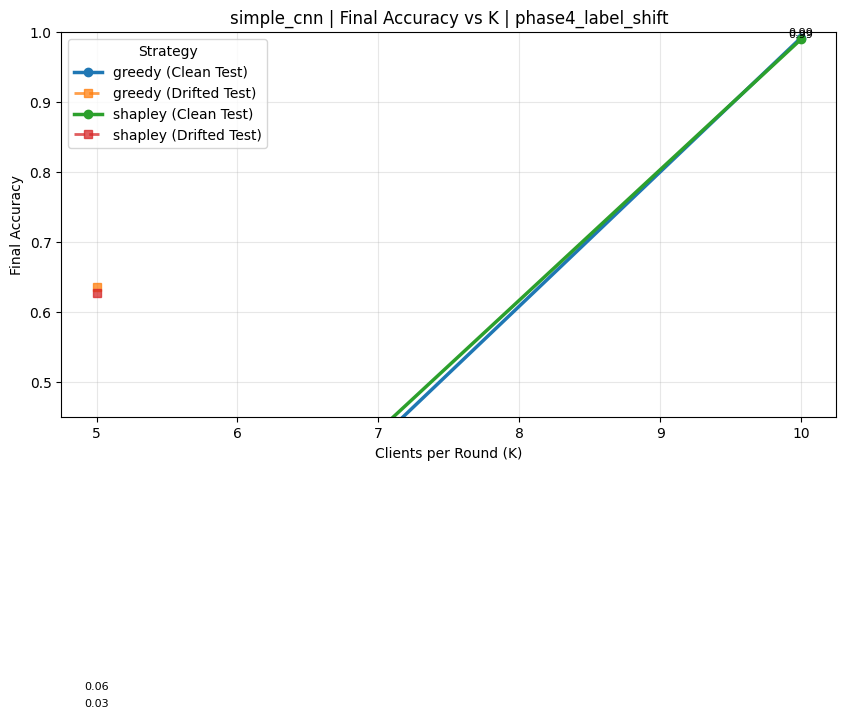

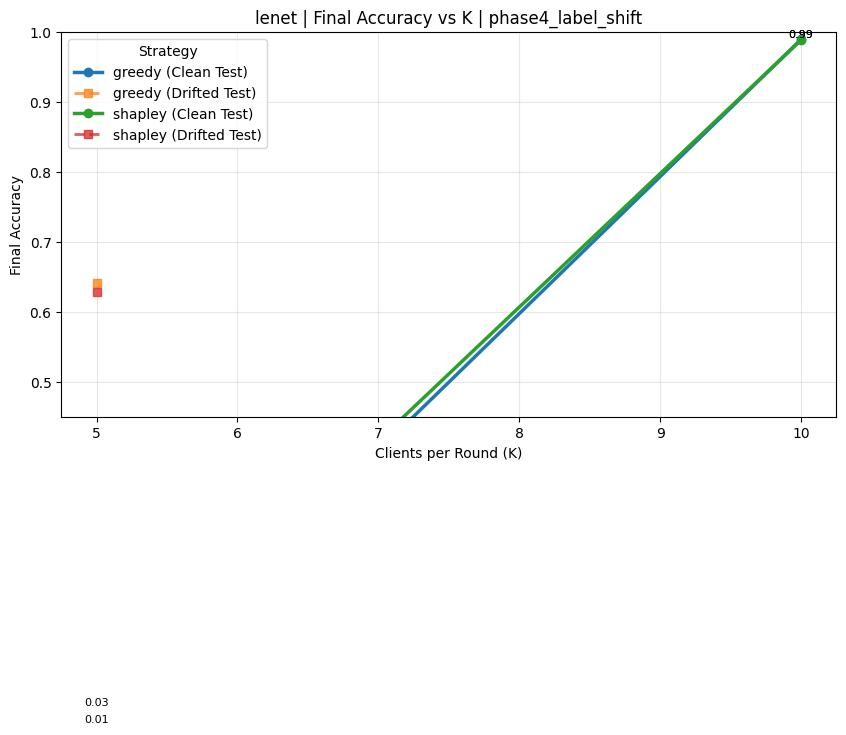

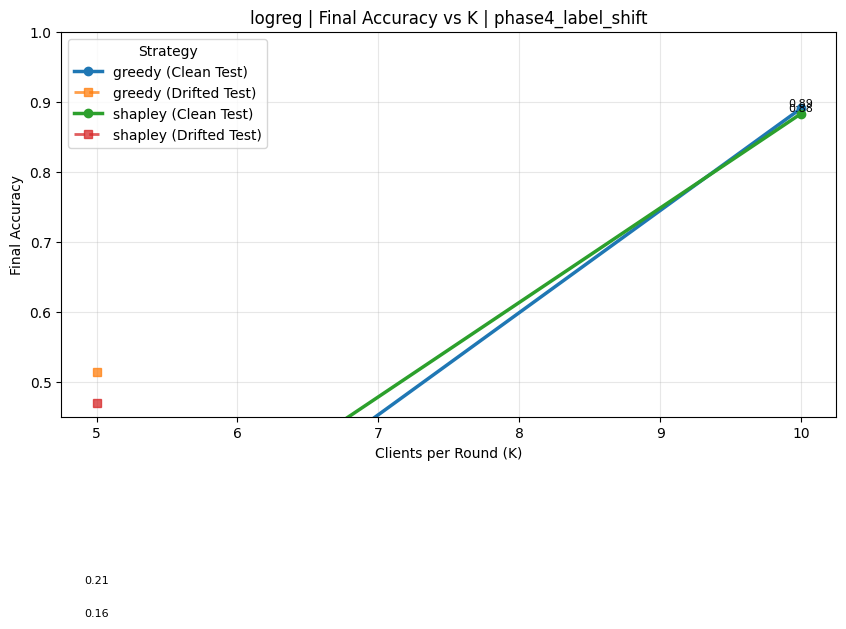

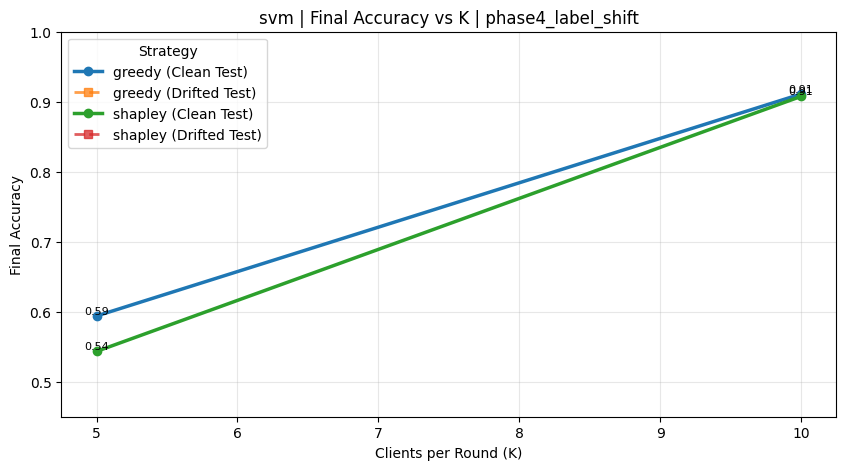

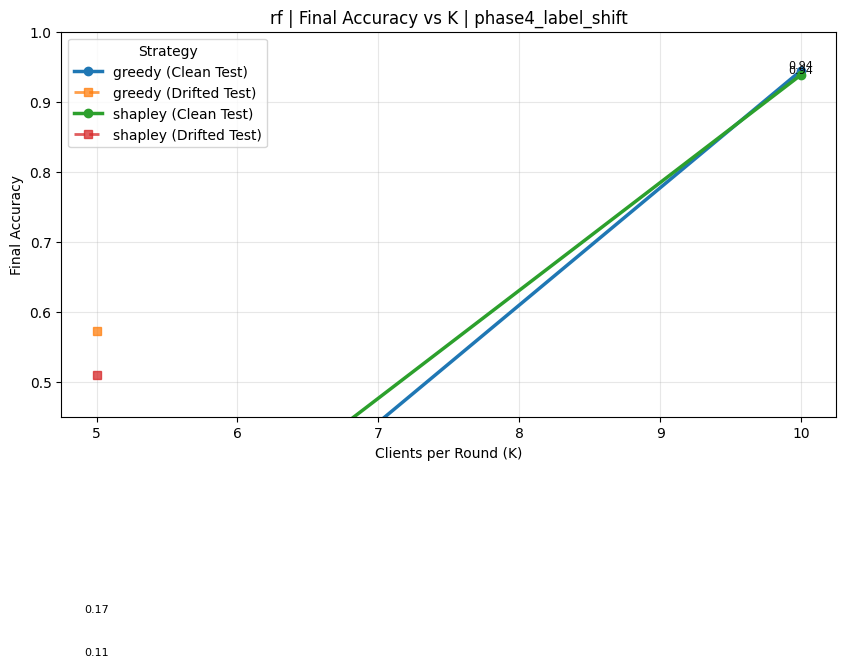


FINAL ACCURACY vs K | DRIFT: phase4_feature_shift


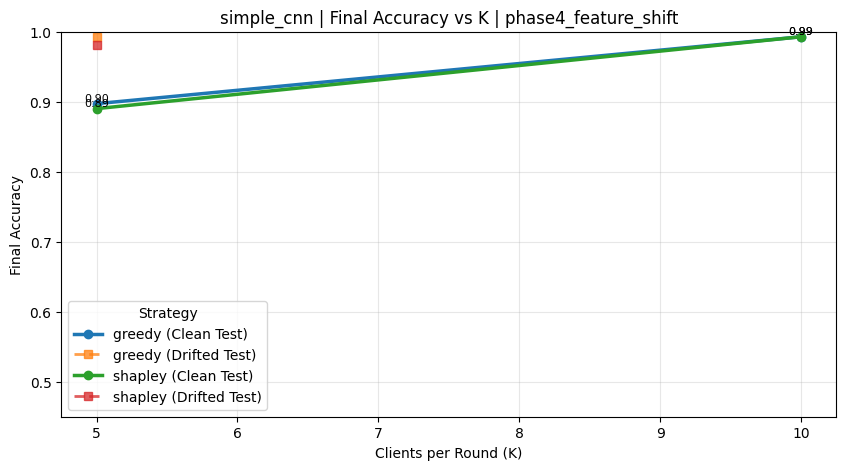

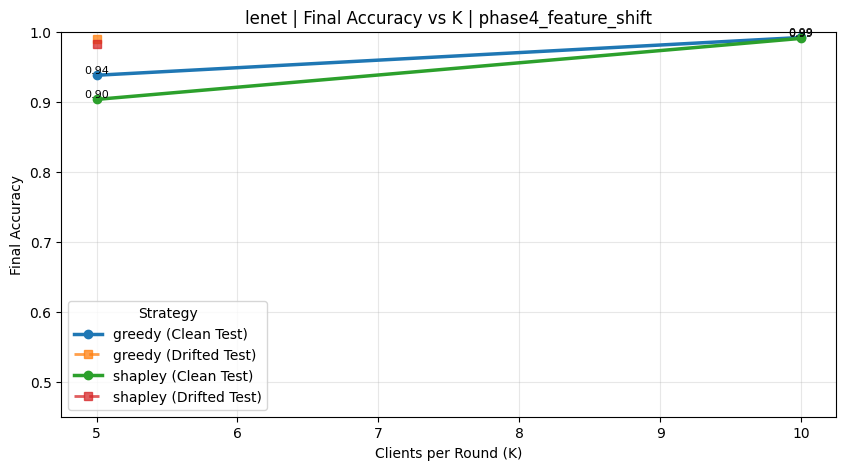

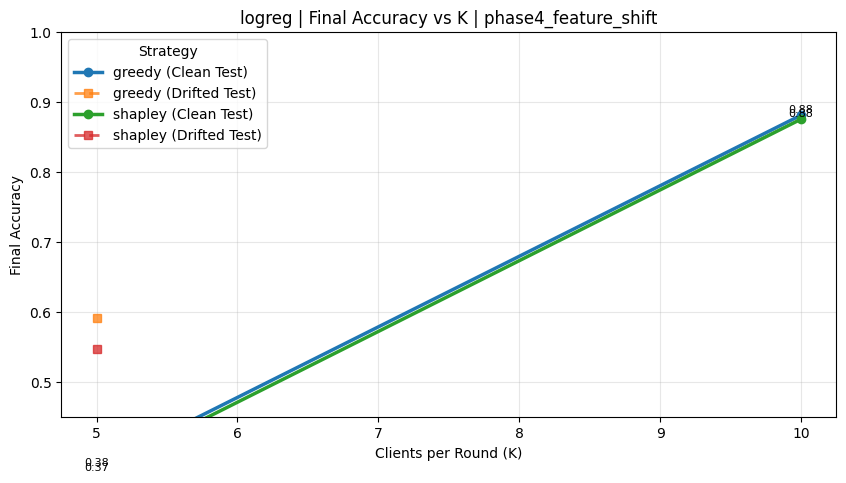

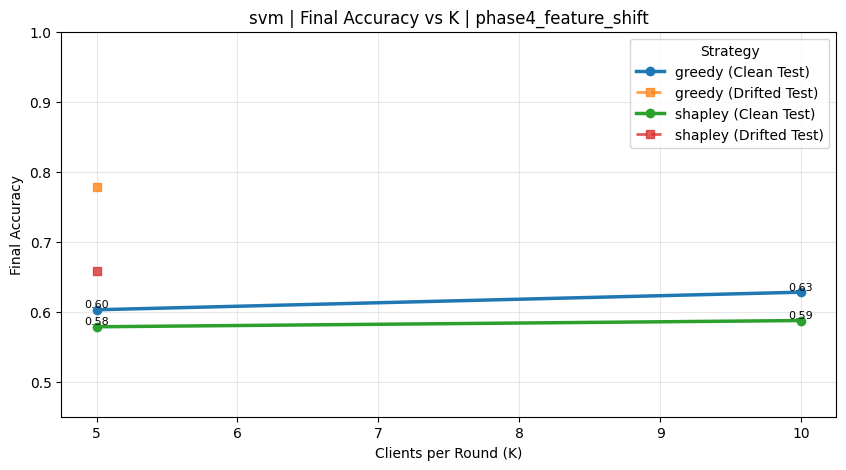

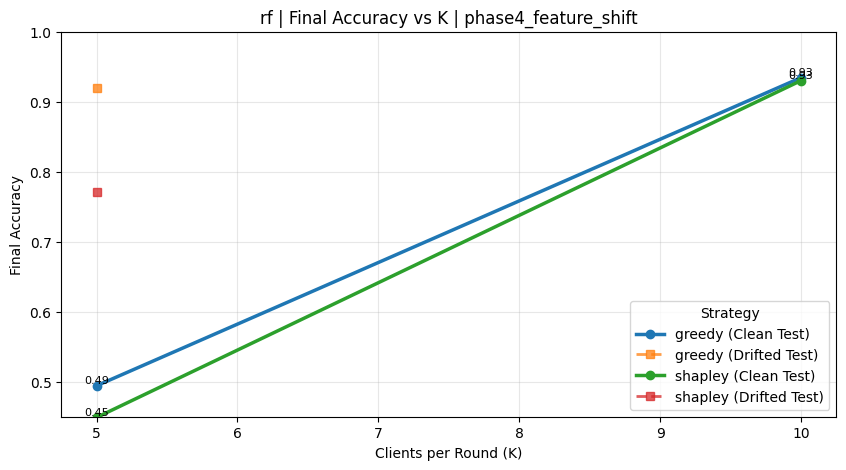

In [20]:
# Compare final accuracy by K

for drift_scenario in DRIFT_SCENARIOS:

    print("\n" + "=" * 70)
    print(f"FINAL ACCURACY vs K | DRIFT: {drift_scenario}")
    print("=" * 70)

    subset = task2_summary_df[
        task2_summary_df["drift_scenario"] == drift_scenario
    ].copy()

    if subset.empty:
        print("No data available for this drift scenario")
        continue

    for model_name in MODEL_NAMES:

        sub_model = subset[
            subset["model"] == model_name
        ]

        if sub_model.empty:
            continue

        plt.figure(figsize=(10, 5))

        for strategy in STRATEGIES:

            sub = sub_model[
                sub_model["strategy"] == strategy
            ].sort_values("K")

            if sub.empty:
                continue

            plt.plot(
                sub["K"],
                sub["final_clean_accuracy"],
                marker="o",
                linewidth=2.5,
                label=f"{strategy} (Clean Test)"
            )

            if "final_drifted_accuracy" in sub.columns:
                plt.plot(
                    sub["K"],
                    sub["final_drifted_accuracy"],
                    marker="s",
                    linestyle="--",
                    linewidth=2,
                    alpha=0.75,
                    label=f"{strategy} (Drifted Test)"
                )

            for x, y in zip(sub["K"], sub["final_clean_accuracy"]):
                plt.text(
                    x,
                    y,
                    f"{y:.2f}",
                    fontsize=8,
                    ha="center",
                    va="bottom"
                )

        plt.title(
            f"{model_name} | Final Accuracy vs K | {drift_scenario}",
            fontsize=12
        )

        plt.xlabel("Clients per Round (K)")
        plt.ylabel("Final Accuracy")

        plt.ylim(0.45, 1.00)
        plt.grid(True, alpha=0.3)
        plt.legend(title="Strategy")

        plt.show()